In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.mobilenetv2 import MobileNet_V2_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device (use GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Data transforms (MobileNet V2 uses 224x224 input)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (change path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform to val set (no augmentation)
val_dataset.dataset.transform = val_transform

# Data loaders (batch 32 fits 6GB VRAM; ~2GB usage, increase to 64 if possible)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Class names
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train samples: 2088, Val samples: 523


In [3]:
# Load pre-trained MobileNet V2
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Freeze all layers except classifier (transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Modify classifier for 5 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

# Move to GPU
model = model.to(device)

# Print model summary (optional)
print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /home/rifat-cou/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████████████████████████████████| 13.6M/13.6M [00:09<00:00, 1.57MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Only train classifier first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/200 - Train Loss: 0.2516, Train Acc: 0.9210 | Val Loss: 0.3514, Val Acc: 0.8815
Epoch 2/200 - Train Loss: 0.2445, Train Acc: 0.9215 | Val Loss: 0.3559, Val Acc: 0.8834
Epoch 3/200 - Train Loss: 0.2449, Train Acc: 0.9181 | Val Loss: 0.3484, Val Acc: 0.8815
Epoch 4/200 - Train Loss: 0.2462, Train Acc: 0.9215 | Val Loss: 0.3532, Val Acc: 0.8910
Epoch 5/200 - Train Loss: 0.2547, Train Acc: 0.9100 | Val Loss: 0.3471, Val Acc: 0.8929
Epoch 6/200 - Train Loss: 0.2503, Train Acc: 0.9176 | Val Loss: 0.3411, Val Acc: 0.8929
Epoch 7/200 - Train Loss: 0.2625, Train Acc: 0.9080 | Val Loss: 0.3454, Val Acc: 0.8891
Epoch 8/200 - Train Loss: 0.2526, Train Acc: 0.9210 | Val Loss: 0.3514, Val Acc: 0.8891
Epoch 9/200 - Train Loss: 0.2690, Train Acc: 0.9104 | Val Loss: 0.3457, Val Acc: 0.8910
Epoch 10/200 - Train Loss: 0.2579, Train Acc: 0.9114 | Val Loss: 0.3494, Val Acc: 0.8891
Epoch 11/200 - Train Loss: 0.2592, Train Acc: 0.9071 | Val Loss: 0.3490, Val Acc: 0.8872
Epoch 12/200 - Train Loss: 0.2

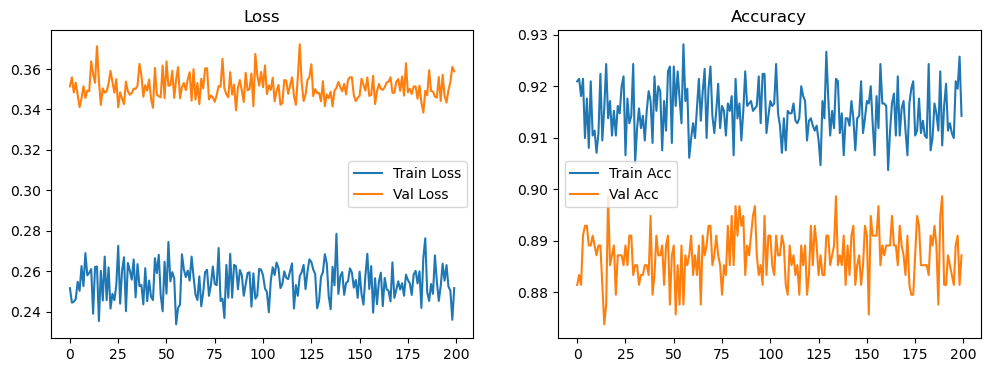

In [8]:
num_epochs = 200
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)  # Adjust LR
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [9]:
# Predictions and report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
MobileNet = os.path.join(model_path, 'MobileNet_V2')
os.makedirs(MobileNet, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(MobileNet, 'mobilenet_v2_200_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.81      0.79      0.80       102
      Cowpox       0.99      0.94      0.96       110
     Measles       0.94      0.94      0.94        88
   MonkeyPox       0.84      0.85      0.84       117
      Normal       0.87      0.92      0.89       106

    accuracy                           0.89       523
   macro avg       0.89      0.89      0.89       523
weighted avg       0.89      0.89      0.89       523

Accuracy: 0.8872
